In [1]:
#Hypothesis 2: The sudden increase in interest is not a long term effect 

In [2]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [3]:
#Search terms for action to scandal:


#how_to_delete_Facebook

#how_to_delete_Facebook_account

#delete_Facebook

#deactivate_Facebook 

#Facebook_privacy_settings

#Facebook_security_settings

In [4]:
path = [ "/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/deactivate_Facebook2.csv", 
"/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/delete_Facebook_account.csv" ,
"/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/delete_Facebook.csv",
"/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/Facebook_privacy_settings.csv",
"/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/Facebook_security_settings.csv",
"/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/how_to_delete_Facebook.csv"]



In [5]:

def loadcsv (path, col_name):
    df = pd.read_csv (path, skiprows = 1, names = ["date", col_name], index_col= "date")

    df[col_name]= pd.to_numeric (df[col_name], errors = "coerce")
    df.index = pd.to_datetime (df.index,errors = "coerce" )

    df = df.dropna().sort_index()
    return df

def add_csv_to_df(path, col_name, old_df):
    
    new_df = pd.read_csv(path, skiprows=1, names = ["date", col_name], index_col="date")
    new_df[col_name]= pd.to_numeric(new_df[col_name], errors = "coerce")
    new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
    new_df = new_df.dropna().sort_index()

    merged_df = pd.concat([old_df, new_df], axis = 1, join = "outer")
    merged_df.head()
    return merged_df
    

In [6]:
dfdeactivate_Facebook2 = loadcsv (
    "/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/deactivate_Facebook2.csv","deactivate_Facebook2"
)

dfdelete_Facebook_account = loadcsv (
    "/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/delete_Facebook_account.csv" , "delete_Facebook_account"
)

dfdelete_Facebook = loadcsv (
    "/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/delete_Facebook.csv","delete_Facebook"
)

dfFacebook_privacy_settings = loadcsv (
    "/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/Facebook_privacy_settings.csv","Facebook_privacy_settings"
)


dfFacebook_security_settings = loadcsv (
    "/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/Facebook_security_settings.csv","Facebook_security_settings"
)

dfhow_to_delete_Facebook = loadcsv (
"/Users/antonialea/fcss2025-fpg3/Data_retrieval/new_files/action_to_scandal/how_to_delete_Facebook.csv","how_to_delete_Facebook."
)

/var/folders/w_/48tvy8kj7pn5d55bs58cjfc00000gn/T/ipykernel_18026/966915858.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/w_/48tvy8kj7pn5d55bs58cjfc00000gn/T/ipykernel_18026/966915858.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/w_/48tvy8kj7pn5d55bs58cjfc00000gn/T/ipykernel_18026/966915858.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/w_/48tvy8kj7pn5d55

In [7]:
#using the mean interest across search terms
#keyword kurz mal rausgenommen wegen beschränkung auf mai, security settings

dfmerged = pd.concat (
    [dfdelete_Facebook,dfdeactivate_Facebook2,dfdelete_Facebook_account,dfFacebook_privacy_settings,dfhow_to_delete_Facebook],
    axis = 1, join = 'inner'
)

dfmerged ["interest"]= dfmerged.mean(axis = 1)

dfmerged

,delete_Facebook,deactivate_Facebook2,delete_Facebook_account,Facebook_privacy_settings,how_to_delete_Facebook.,interest
date,,,,,,
2018-02-16,37.0,45.0,44.0,15.0,42.0,36.6
2018-02-17,43.0,44.0,52.0,0.0,49.0,37.6
2018-02-18,42.0,55.0,56.0,20.0,50.0,44.6
2018-02-19,40.0,51.0,45.0,20.0,44.0,40.0
2018-02-20,37.0,44.0,45.0,27.0,42.0,39.0
...,...,...,...,...,...,...
2018-10-08,45.0,66.0,47.0,16.0,55.0,45.8
2018-10-09,36.0,56.0,44.0,16.0,41.0,38.6
2018-10-10,33.0,56.0,39.0,16.0,40.0,36.8


In [8]:
# the week after the event compared to 3? months after
#still need to figure out the actual time sequence we want to use 
# whtiney u test für 3m vs 6m 
#ergebnis scheint relevant mit effect size = 0.72 grosser effekt
#mit deactivate facebook inkludiert nur noch 0.66
scandalpublic = pd.Timestamp("2018-3-17")

post_event14 = dfmerged.loc[scandalpublic : scandalpublic + pd.Timedelta(days=14)]
post_event3m=  dfmerged.loc[scandalpublic + pd.Timedelta(days=14) : scandalpublic + pd.Timedelta(days=90)]
post_event6m=  dfmerged.loc[scandalpublic + pd.Timedelta(days=14) : scandalpublic + pd.Timedelta(days=180)]

stat, p_value = mannwhitneyu(
    post_event3m["interest"],
    post_event6m["interest"],
    alternative="greater"
)

print("Analysis for 14 days after publication of scandal and 90 days after")
print("U:", stat)
print("p-value:", p_value)
print("Mean post14:", post_event14["interest"].mean())
print("Mean post3m:", post_event3m["interest"].mean())
print("Mean post6m:", post_event6m["interest"].mean())
print("Δ mean:", post_event14["interest"].mean() - post_event3m["interest"].mean())



n1 = len(post_event3m)
n2 = len(post_event6m)

effect_size = stat / (n1 * n2)
print("Effect size ", effect_size)

Analysis for 14 days after publication of scandal and 90 days after
U: 8518.5
p-value: 2.2828818810524967e-05
Mean post14: 63.26666666666667
Mean post3m: 43.270129870129864
Mean post6m: 40.119760479041915
Δ mean: 19.99653679653681
Effect size  0.6624543121549109


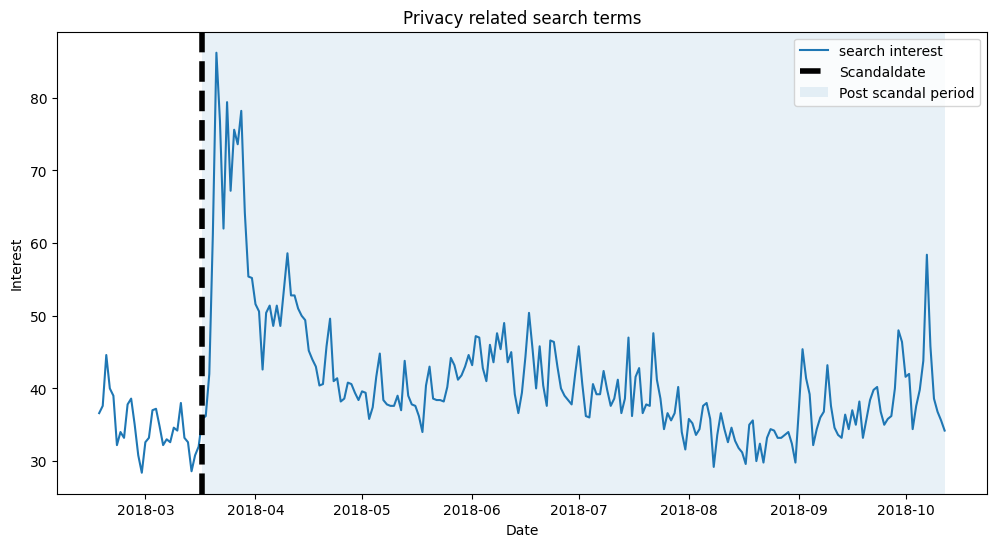

In [9]:
plt.figure(figsize = (12,6))
plt.plot(dfmerged.index, dfmerged["interest"], label = "search interest")

plt.axvline (scandalpublic, linewidth = 4, color = "black", linestyle = "--", label = "Scandaldate")

plt.axvspan (
    scandalpublic, dfmerged.index.max(),alpha=0.1, label = "Post scandal period"
)

plt.title ("Privacy related search terms")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.show()
#basically nur nochmal der plot eben bis oktober zu sehen 
